### Detecting Differences between Natural Selection and Genetic Drift in Time Series Data

#### Nikolay Oskolkov, SciLifeLab, NBIS Long Term Support, [nikolay.oskolkov@scilifelab.se](nikolay.oskolkov@scilifelab.se)

<h3><center>Abstract</center></h3>
In this notebook, we will learn how to discriminate white noise (random Gaussian signal) from meaningful signal in time series data. We will also attempt to see the differences in statistical properties between genetic drift (random walk) and selection signal.

### Table of Contents:
* [White Noise vs. Signal in Time Series](#White-Noise-vs.-Signal-in-Time-Series)
* [Random Walk vs. Signal in Time Series](#Random-Walk-vs.-Signal-in-Time-Series)
* [Genetic Drift vs. Natural Selection in Time Series](#Genetic-Drift-vs.-Natural-Selection-in-Time-Series)

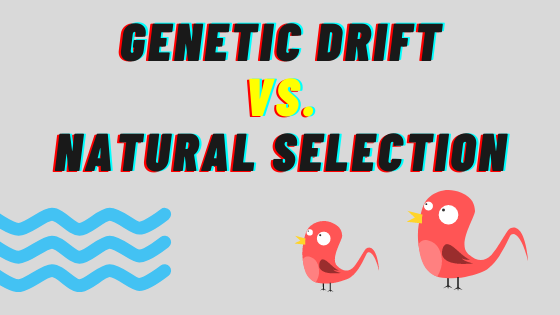

In [1]:
from IPython.display import Image
Image('/home/nikolay/WABI/A_Gotherstrom/KrakenUniq/Mammoths/variant_traj/figures/DriftSelection.png',width=2000)

### White Noise vs. Signal in Time Series <a class="anchor" id="White-Noise-vs.-Signal-in-Time-Series"></a>

Gaussian **white noise** is a good baseline time series to start with. It is defined as a signal $\epsilon(t)$ with zero mean, constant variance and absence of correlations between any pair of time points:


$$E\left[\epsilon(t)\right] = 0$$

$$\text{Cov}\left[\epsilon(t), \epsilon(t+k)\right] = \left\{\begin{aligned}
&\gamma^2 && \text{if} \enspace k = 0 \\
&0 && \text{if} \enspace k \neq 0
\end{aligned}
\right.$$

In other words, white noise does not have any memory, the next step is completely random and does not remember the previous step. Now let us slightly modify the white noise model and include some correlation with the previous steps. For example, we will ask that an observation at time step t is not purely random (white noise) but depends on the white noise values on three previous steps. This is called a **moving average (MA) process**:

$$\rm{X(t)}=\epsilon(t) + \theta_1\epsilon(t-1) + \theta_2\epsilon(t-2) + \theta_3\epsilon(t-3)$$


While white noise is a purely random, memoryless and stationary process, MA is weakly non-stationary and has some memory. Let us simulate white noise and MA signal and see whether we are able to see any difference visually.

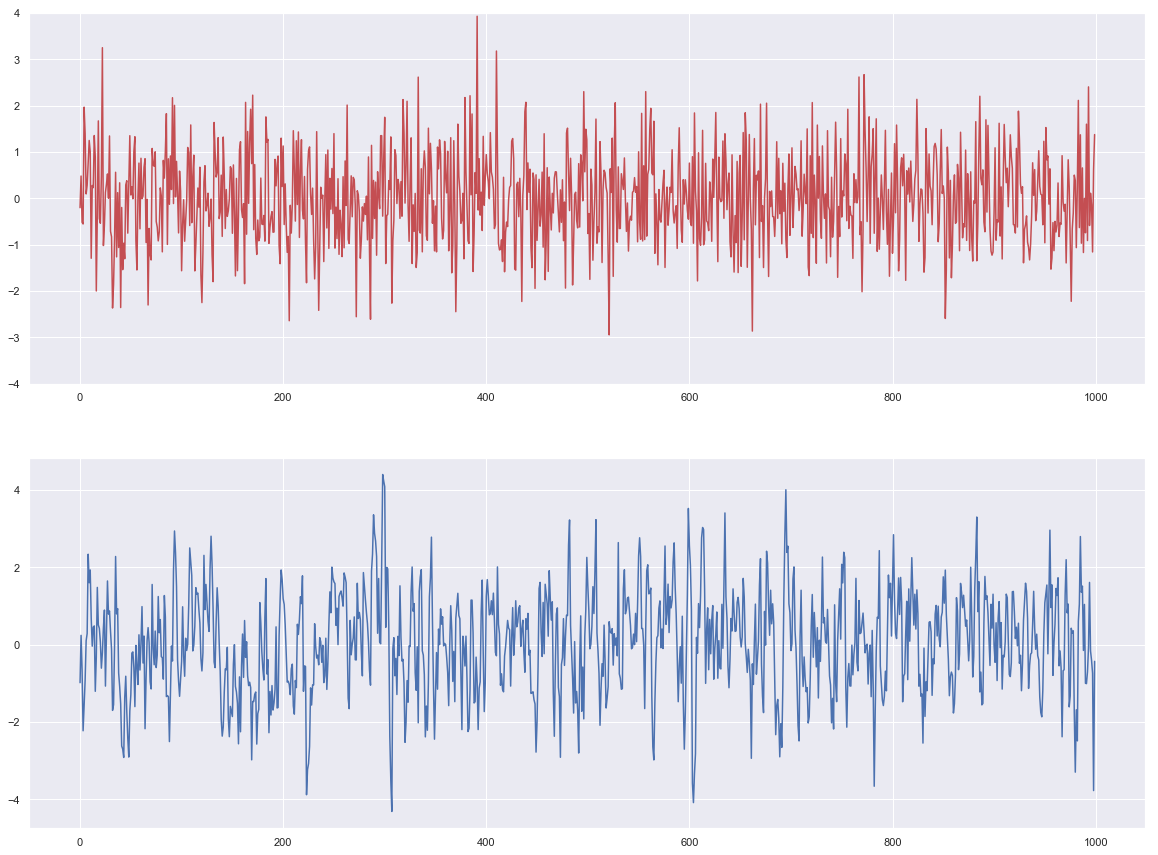

In [2]:
%matplotlib inline

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.arima_process import ArmaProcess

import warnings
warnings.filterwarnings('ignore')

sns.set()

np.random.seed(12345)

# Generate Gaussian white noise dist with mean 0 and 0.5 std
white_noise = np.random.normal(loc = 0, scale = 1, size = 1000)

# Generate ARMA correlated meaningful signal with information
ar = np.array([1]) #specifying ar = np.array([1]) we demand a pure MA (and not ARMA) process, i.e. skip AR
ma = np.array([1, 0.7, 0.5, 0.3]) #theta1, theta2 and theta3 coeeficients in the MA process model above
simulated_ARMA_data = ArmaProcess(ar, ma).generate_sample(nsample = 1000)

# Plot white noise and meaningful signal next to each other
plt.figure(figsize = (20, 15))
plt.subplot(2, 1, 1)
plt.plot(white_noise, color = 'r')
plt.ylim([-4, 4])

plt.subplot(2, 1, 2)
plt.plot(simulated_ARMA_data)

plt.show()

It is very hard to visually see any difference between the two time series. Therefore we have to use some mathematical statistics to really detect that those are two very different time series: one dies not have any inforamtion, the other one does. One way is to compute an autocorrelation function and see how it looks like for both.

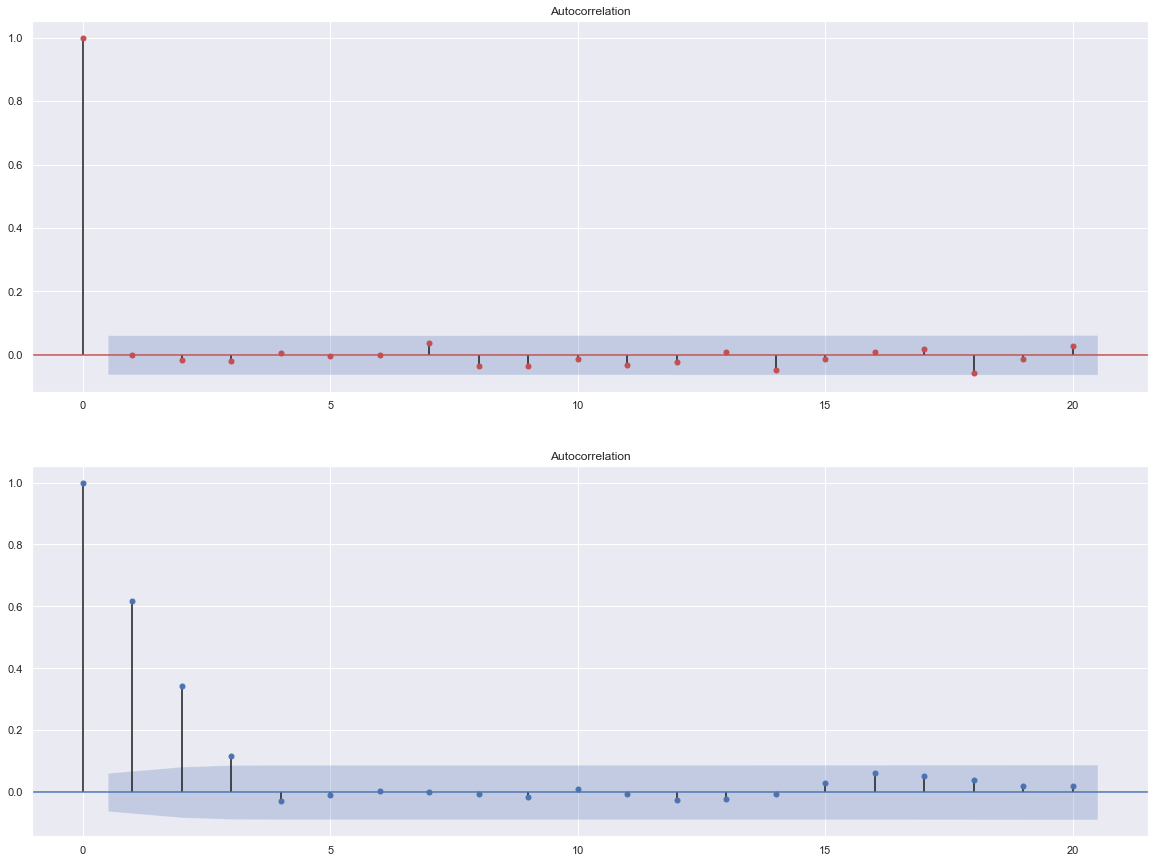

In [3]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(2,1,figsize = (20, 15))

plot_acf(white_noise, lags = 20, color = 'r', ax = ax[0])
plot_acf(simulated_ARMA_data, lags = 20, color = 'b', ax = ax[1])

plt.show()

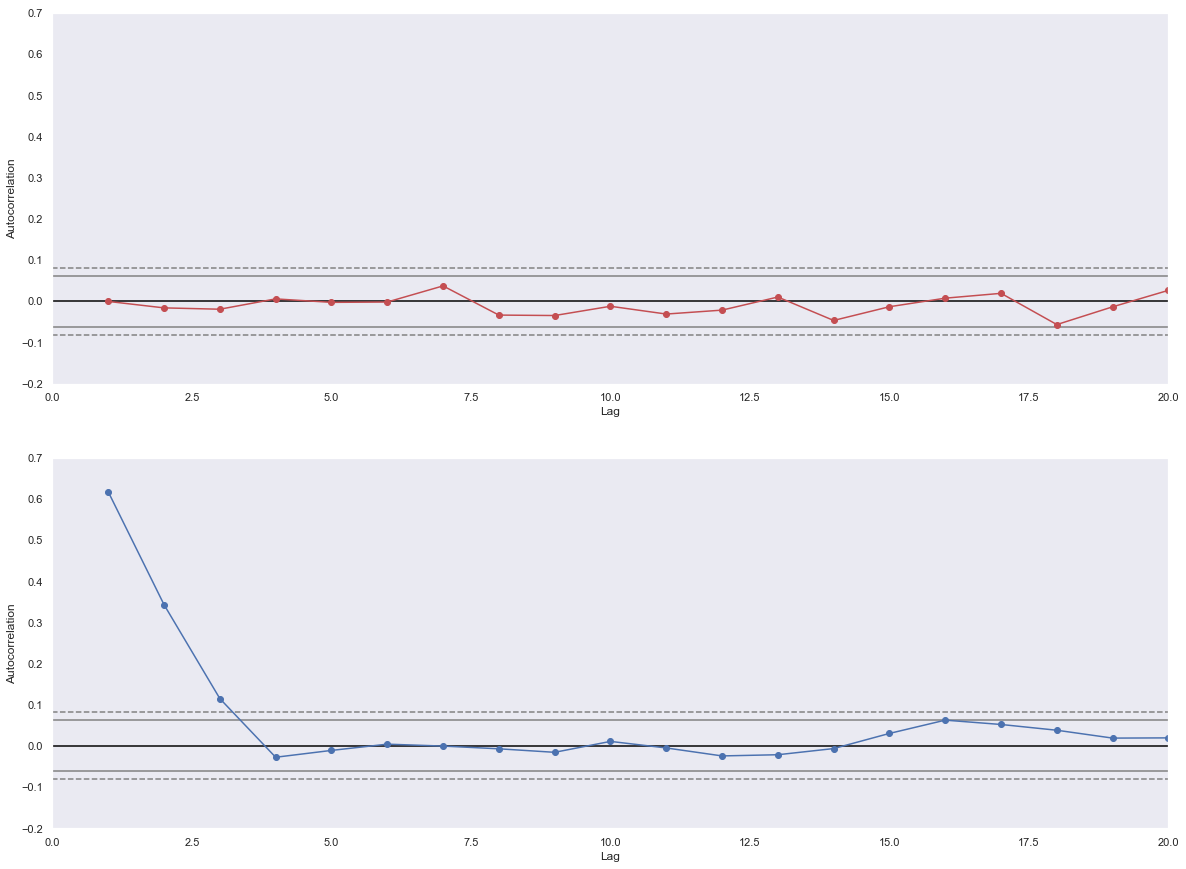

In [4]:
from pandas.plotting import autocorrelation_plot

fig, ax = plt.subplots(2, 1, figsize = (20, 15))

ax[0].set_ylim([-0.2, 0.7])
ax[1].set_ylim([-0.2, 0.7])

autocorrelation_plot(white_noise, color = 'r', ax = ax[0], marker = 'o').set_xlim([0, 20])
autocorrelation_plot(simulated_ARMA_data, color = 'b', ax = ax[1], marker = 'o').set_xlim([0, 20])

plt.show()

We can clearly see a difference between autocorrelation functions from the white noise and MA simulated signal. All the points in the autocorrelation function from white noise are within the 95% (two standard deviations from the mean) confidence interval, while at least two points in the autocorrelation function from the MA simulated signal are outside of the confidence intervals. This means that there is a memory / correlation between the time points, i.e. each step "remembers" approximately two previous steps.

The confidence intervals at the autocorrelation plots are computed using the so-called **Bartlett's method**. The idea of the method is that it can be proven that autocorrelation coefficients r(k) (correlation coefficients between consequtive time points, i.e. values on the y-axis of the autocorrelation plot) for different lags k follow a Gaussian distribution with the variance:

$$\rm{Var}\left[r(k)\right] \equiv \gamma^2 = \frac{1}{N}\left[1+2(r(1)^2+r(2)^2+...+r(k-1)^2)\right], \,\,\,\text{where N is the number of time points}$$

This results in the first increasing, then flattening confidence level shown above.

### Random Walk vs. Signal in Time Series <a class="anchor" id="Random-Walk-vs.-Signal-in-Time-Series"></a>

Now we will learn to discriminate between random walk and a signal in time series data. Random walk is a white noise time series that has a trend, this is because each step rememebrs the previous step but not more than one step. 

$$\rm{X}(\rm{t}) = \rm{X}(\rm{t} - 1) + \epsilon(\rm{t})$$


It turns out the mean of this process is still zero while the variance is not constant any more but depends linearly on time:

$$\text{Cov}\left[X(t), X(t-k)\right] = \gamma^2 (t-k) $$

Visually it looks like a meaningful signal but it is not, it actually does not contain any information. Let us plot a random walk and a CSS prevalence data next to each other and see whether we can visually detect any difference between them.

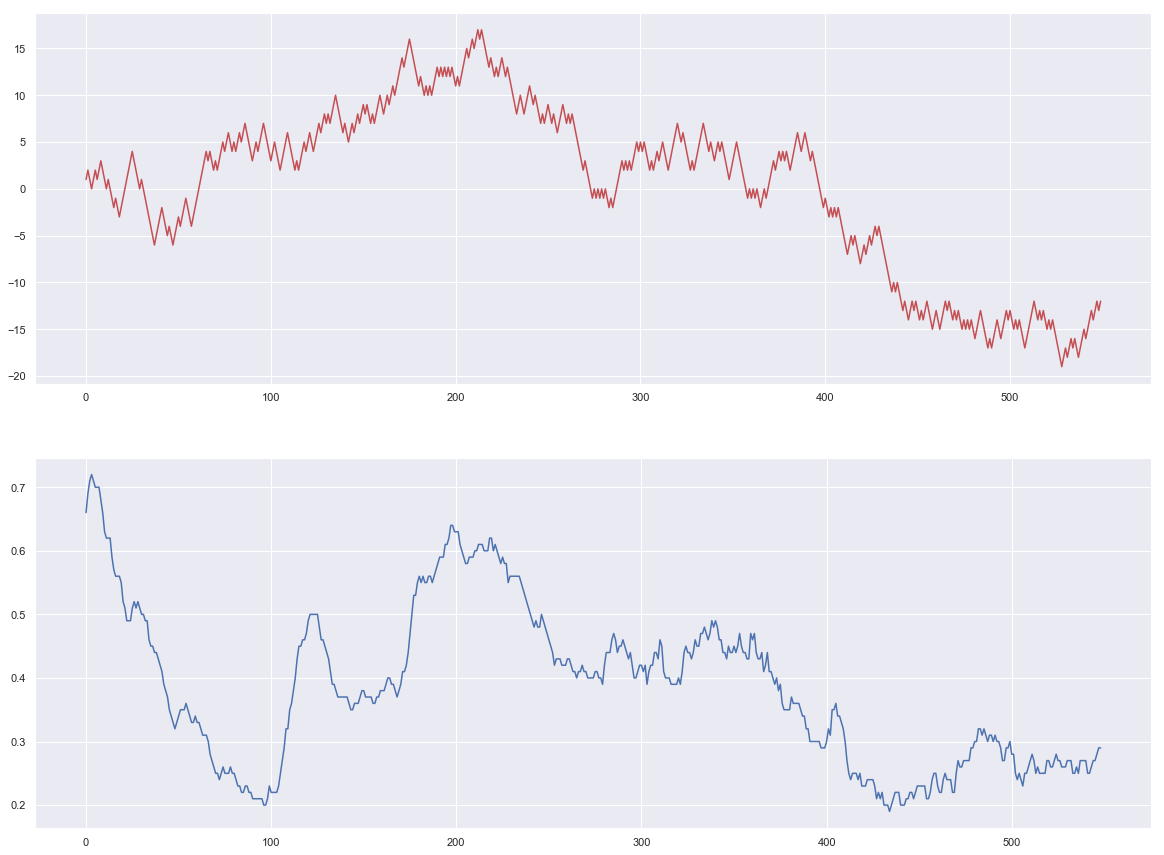

In [57]:
import pandas as pd

np.random.seed(123)

random_walk = [1]
for i in range(549):
    # Create random noise
    noise = -1 if np.random.random() < 0.5 else 1
    random_walk.append(random_walk[-1] + noise)

css = pd.read_csv("/home/nikolay/WABI/P_Franks/time_series/nationella_senaste.csv")    
css = css['Uppskattning']    
    
# Plot white noise and meaningful signal next to each other
plt.figure(figsize = (20, 15))
plt.subplot(2, 1, 1)
plt.plot(random_walk, color = 'r')

plt.subplot(2, 1, 2)
plt.plot(css)
    
plt.show()

Again, it is very hard to visually predict which time series is a random walk and which one is the covid19 national prevalence in Sweden (CSS data). We need statistical means to confidently assess each of the two time series. However, in this case, computing an autocorrelation functions will not be enough, they both will show some correlation present in the time series data because random walk by design has a short, i.e. just one step memory. Let us demonstrate it here.

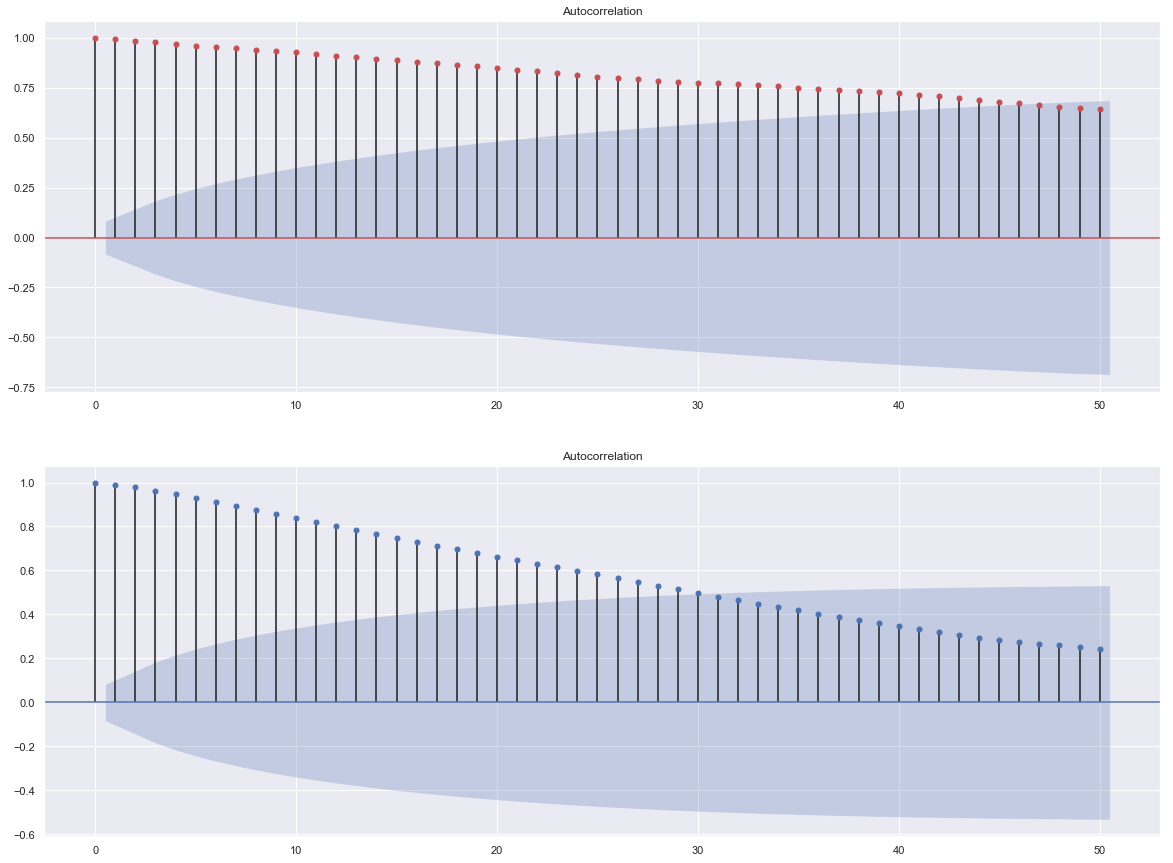

In [58]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(2,1,figsize = (20, 15))

plot_acf(random_walk, lags = 50, color = 'r', ax = ax[0])
plot_acf(css, lags = 50, color = 'b', ax = ax[1])

plt.show()

We can see that both time series have significant correlations present in them. Actually they both have a decreasing profiles in agreement with the equation for random walk covariance above that has is **negatively** and linearly related to the number of lags k. The presence of autocorrelations (i.e. **non-stationary** process) comes from the fact that both time series above have a non-zero mean, i.e. the trend is present. Recall, that White Noise had a zero mean, this is why autocorrelation function was enough to detect which one was a signal without any information (White Noise). Here, we will have to remove the one step correlation implemented in the random walk by design using the diff() function in Python.

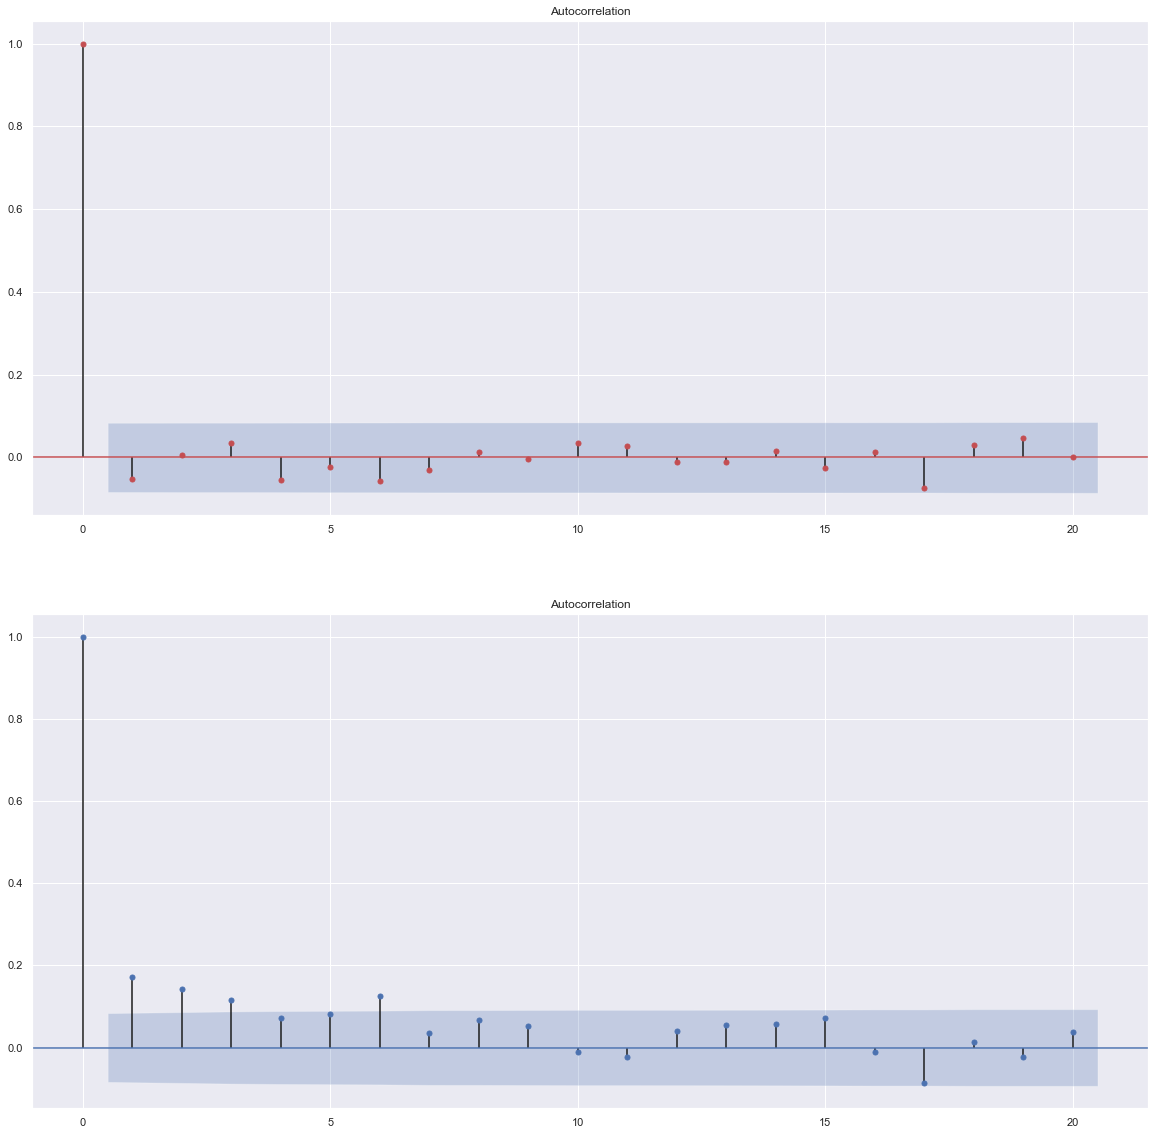

In [59]:
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(2,1,figsize = (20, 20))

plot_acf(pd.Series(random_walk).diff().dropna(), lags = 20, color = 'r', ax = ax[0])
plot_acf(pd.Series(css).diff().dropna(), lags = 20, color = 'b', ax = ax[1])

plt.show()

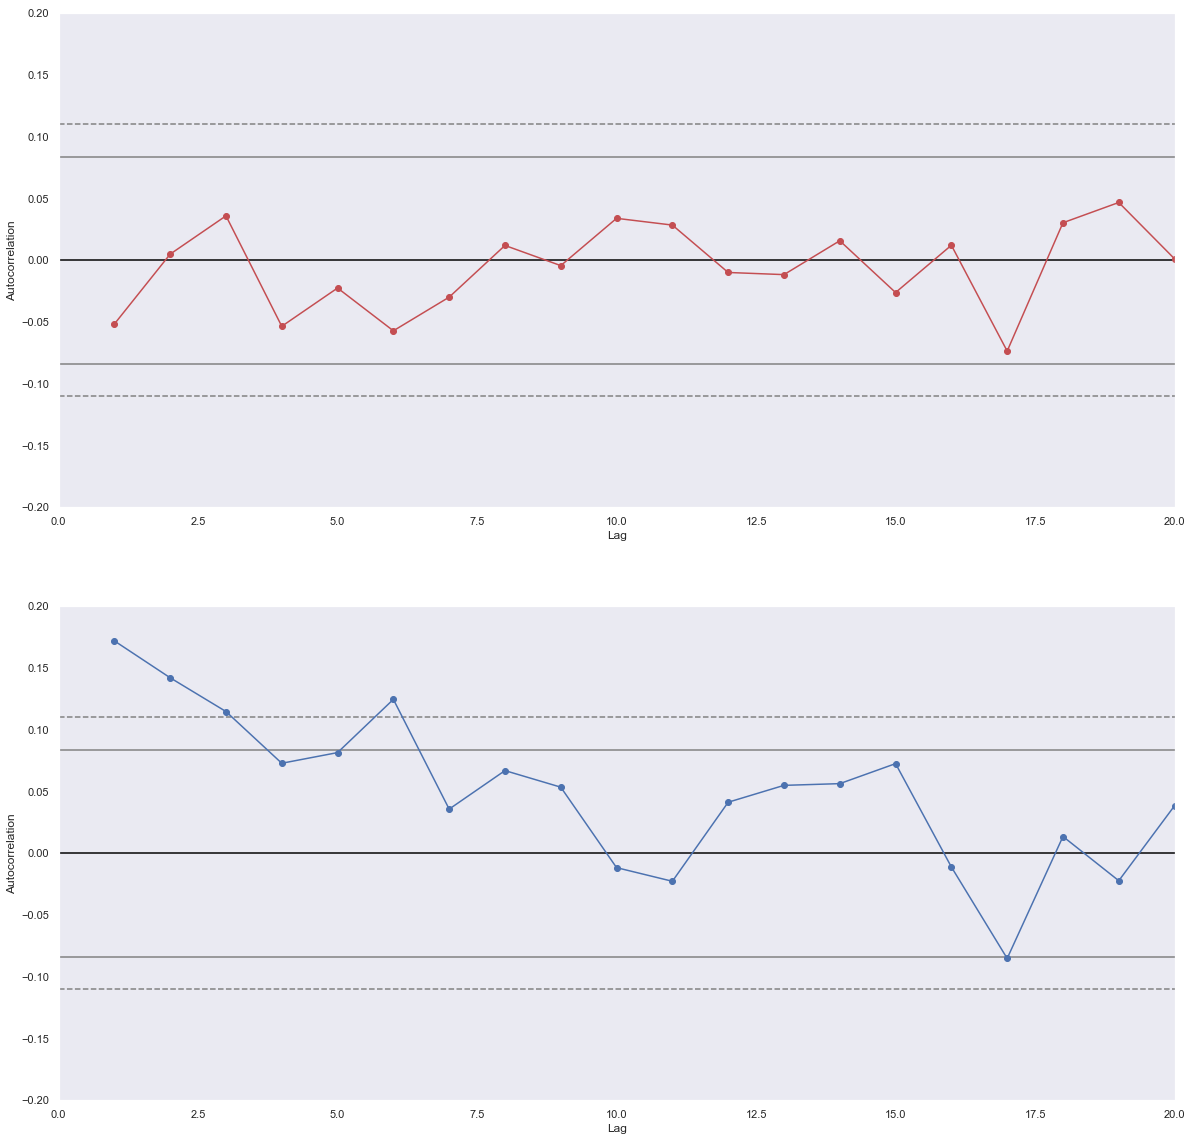

In [60]:
from pandas.plotting import autocorrelation_plot

fig, ax = plt.subplots(2, 1, figsize = (20, 20))

ax[0].set_ylim([-0.2, 0.2])
ax[1].set_ylim([-0.2, 0.2])

autocorrelation_plot(pd.Series(random_walk).diff().dropna(), color = 'r', ax = ax[0], 
                     marker = 'o').set_xlim([0, 20])
autocorrelation_plot(pd.Series(css).diff().dropna(), color = 'b', ax = ax[1], marker = 'o').set_xlim([0, 20])

plt.show()

Now, suddenly we can see which one is a rndom walk and which one is the CSS national prevalence signal, i.e. has some meaningful information. This is because at least two points in the second / blue plot are beyond the confidence intervals and therefore are statistically significant.

Another useful thig one could do to immediately estimate which time series is a random walk is the Augmented Dickey-Fuller test, which simply tests whether the time series satisfies the following equation:


$$\rm{X}(\rm{t}+1) = \rm{X}(\rm{t}) + \beta \, \rm{t}  + \epsilon(\rm{t})$$

and whether $\beta$ is different from zero. If it is, then we get the random walk equation. However, if $\beta$ is significantly different from zero, it indicates some memory (long-range) correlations present in the time series data. Let us perfrom the Augmented Dickey-Fuller test on both time series.

In [61]:
from statsmodels.tsa.stattools import adfuller

results = adfuller(random_walk)

print(f"ADF Statistic: {results[0]}")
print(f"p-value: {results[1]}")
print("Critical Values:")
for key, value in results[4].items():
    print("\t%s: %.3f" % (key, value))

ADF Statistic: -0.9488141995967303
p-value: 0.7714726849123716
Critical Values:
	1%: -3.442
	5%: -2.867
	10%: -2.570


In [62]:
from statsmodels.tsa.stattools import adfuller

results = adfuller(css)

print(f"ADF Statistic: {results[0]}")
print(f"p-value: {results[1]}")
print("Critical Values:")
for key, value in results[4].items():
    print("\t%s: %.3f" % (key, value))

ADF Statistic: -2.8860887403399023
p-value: 0.04698976770138257
Critical Values:
	1%: -3.442
	5%: -2.867
	10%: -2.570


Again, we can see that for random walk the p-value is equal to 0.77, i.e. not significant, and we can reject the hypothesis that the time series is a random walk, this means that the **first / red time series is a random walk**. In contrast, the p-value for the second time series is equal to 0.047, i.e. it is significant and we can reject the hypothesis that the second / blue time series is a random walk, it implies that the **second / blue time series is not a random walk**.

### Genetic Drift vs. Natural Selection in Time Series <a class="anchor" id="Genetic-Drift-vs.-Natural-Selection-in-Time-Series"></a>

Now we are going to use the method of autocorrelation functions to try to discriminate between time series from a genetic drift and time series from a natural selection process. 

Let us start with simulating a pure genetic drift, i.e. no selection. Below, we are evolving **n_snp** SNPs with 2 alleles from a population of **N** diploid individuals over **t** time steps (generations). Initially, all SNPs had allele frequency **freq0**, and after each generation this frequency is updated to **freq**. Allele population counts are drawn from **Binomial distribution** with the probability of Bernoulli trial **p = freq**. This model is called the **Wright-Fisher model** of genetic drift and it assumes: 

* no selection
* no mutation
* no migration
* non-overlapping generation times
* asexual reproduction
* random mating
* constant (and finite) population size between generations

From the code below, we can see that genetic drift is nothing else as a random walk since allele frequency at each step $\rm{freq[i+1]}$ depends on the allele frequency at the previous step $\rm{freq[i]}$ only, i.e. similar to Markov chain.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set()
np.random.seed(1)

# Allele counts follow binomial distribution: aka flipping a coin 500 times, tested 1000 times
N = 100        # population size
t = 100        # number of time points
freq0 = 0.5    # initial allele frequency
n_snp = 100    # number of SNPs

freq = np.empty(t + 1)
freq[0] = freq0
drift_df = pd.DataFrame(columns = [('t' + str(j)) for j in range(t)], 
                        index = [('snp' + str(j)) for j in range(n_snp)])
for j in range(n_snp):
    for i in range(t):
        freq[i + 1] = np.random.binomial(2*N, freq[i], 1) / (2*N)
        drift_df.loc['snp' + str(j), 't' + str(i)] = freq[i + 1]

drift_df.iloc[0:15, 0:20]

,t0,t1,t2,t3,t4,t5,t6,t7,t8,t9,t10,t11,t12,t13,t14,t15,t16,t17,t18,t19
snp0,0.5,0.48,0.49,0.49,0.5,0.505,0.54,0.58,0.565,0.56,0.565,0.555,0.59,0.605,0.53,0.545,0.59,0.605,0.62,0.705
snp1,0.425,0.44,0.405,0.39,0.405,0.39,0.335,0.38,0.38,0.345,0.33,0.35,0.385,0.405,0.37,0.37,0.355,0.32,0.3,0.245
snp2,0.48,0.475,0.5,0.535,0.545,0.595,0.6,0.55,0.485,0.435,0.44,0.47,0.45,0.43,0.44,0.465,0.48,0.49,0.495,0.49
snp3,0.46,0.49,0.505,0.485,0.455,0.48,0.515,0.53,0.555,0.58,0.6,0.57,0.575,0.595,0.595,0.59,0.685,0.685,0.685,0.705
snp4,0.495,0.475,0.44,0.485,0.53,0.46,0.445,0.48,0.43,0.44,0.44,0.485,0.46,0.505,0.44,0.46,0.48,0.53,0.53,0.58
snp5,0.505,0.465,0.47,0.475,0.455,0.47,0.44,0.415,0.425,0.435,0.47,0.495,0.42,0.395,0.425,0.415,0.435,0.435,0.36,0.36
snp6,0.565,0.49,0.485,0.55,0.53,0.58,0.545,0.58,0.58,0.59,0.565,0.63,0.66,0.595,0.58,0.535,0.585,0.575,0.56,0.535
snp7,0.515,0.615,0.615,0.65,0.61,0.605,0.635,0.65,0.675,0.66,0.715,0.745,0.725,0.72,0.72,0.715,0.735,0.725,0.7,0.645
snp8,0.495,0.545,0.52,0.54,0.5,0.515,0.485,0.445,0.435,0.45,0.445,0.44,0.415,0.355,0.375,0.37,0.37,0.385,0.4,0.39
snp9,0.475,0.445,0.45,0.43,0.345,0.35,0.355,0.335,0.33,0.385,0.36,0.365,0.36,0.305,0.285,0.27,0.275,0.275,0.255,0.26


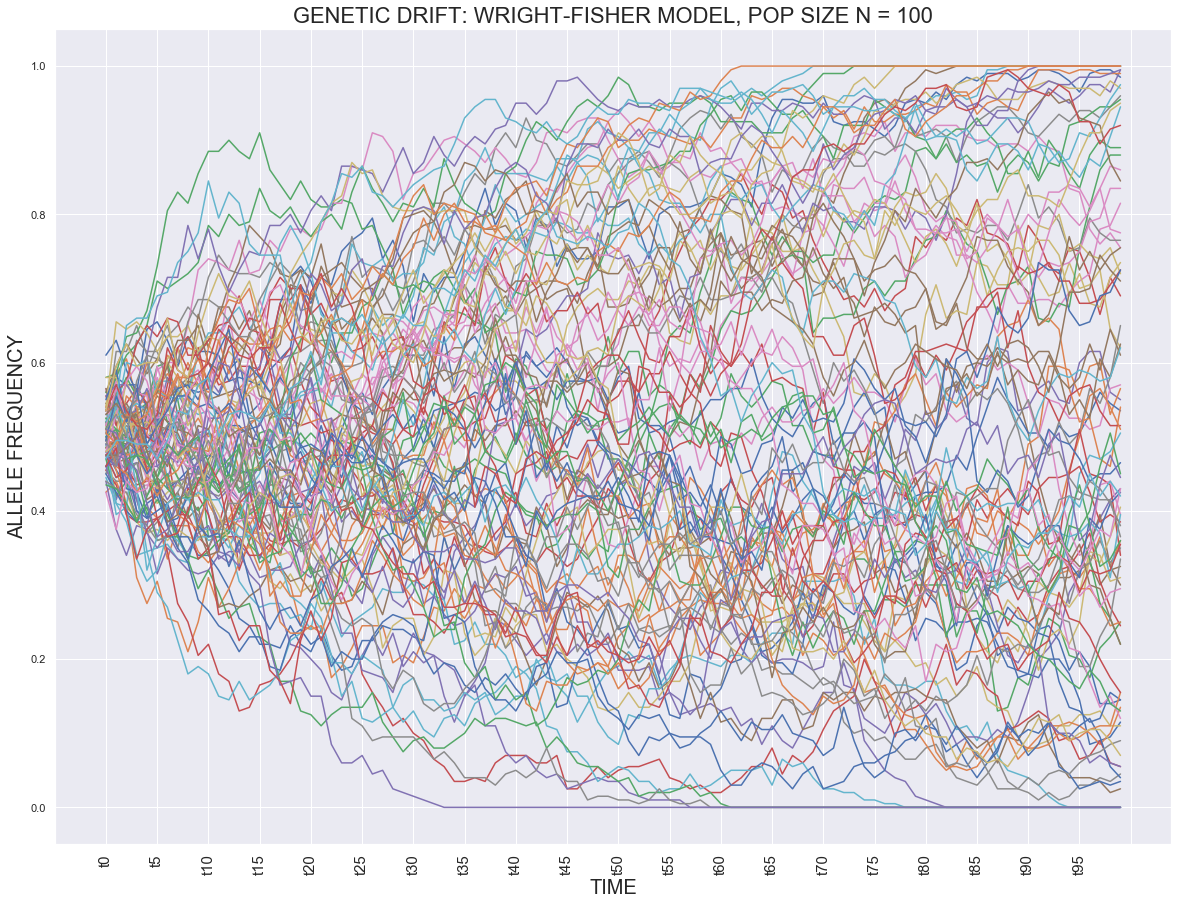

In [2]:
from pylab import rcParams
rcParams['figure.figsize'] = 20, 15
plt.rcParams.update({'font.size': 22})

drift_df.T.plot(legend = False)

plt.xticks(np.arange(0, len(list(drift_df.T.index)) + 1, 5), list(drift_df.T.index)[::5], 
           fontsize = 15, rotation = 90)
plt.ylabel('ALLELE FREQUENCY', fontsize = 20)
plt.xlabel('TIME', fontsize = 20)
plt.title('GENETIC DRIFT: WRIGHT-FISHER MODEL, POP SIZE N = ' + str(N), fontsize = 22)

plt.show()

We can see that genetic drift can lead to allele fixation after t generations. Now we will add a selection pressure into the Wright-Fisher model via the selection coefficient **s** that implies some fitness benifit at s > 0, or fitness deleterious effect at s < 0. Since we are evolving SNPs / genes, i.e. not really individuals (not haplotypes), the fitness of a SNP is defined as a number of copies it leaves after each generation.

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set()
#np.random.seed(12345)

# Allele counts follow binomial distribution: aka flipping a coin 500 times, tested 1000 times
N = 100        # population size
t = 100        # number of time points
s = 0.095      # selection coefficient
freq0 = 0.5    # initial allele frequency
n_snp = 100    # number of SNPs

X = np.empty(t + 1)
freq = np.empty(t + 1)
freq[0] = freq0
sel_df = pd.DataFrame(columns = [('t' + str(j)) for j in range(t)], 
                      index = [('snp' + str(j)) for j in range(n_snp)])
for j in range(n_snp):
    for i in range(t):
        X[i] = np.random.binomial(2*N, freq[i], 1)
        freq[i + 1] = X[i]*(1 + s) / (X[i]*(1 + s) + 2*N - X[i]) #X[i] copies of allele a and 2*N-X[i] copies of A
        sel_df.loc['snp' + str(j), 't' + str(i)] = freq[i + 1]

sel_df.iloc[0:15, 0:15]

,t0,t1,t2,t3,t4,t5,t6,t7,t8,t9,t10,t11,t12,t13,t14
snp0,0.522673,0.572345,0.572345,0.646018,0.718706,0.757077,0.79043,0.809395,0.833009,0.851824,0.818853,0.833009,0.861207,0.884593,0.889258
snp1,0.532643,0.587159,0.611761,0.587159,0.557491,0.507683,0.557491,0.631363,0.665497,0.71389,0.818853,0.818853,0.799921,0.809395,0.833009
snp2,0.452371,0.502678,0.577288,0.582226,0.572345,0.611761,0.616668,0.660633,0.70907,0.74751,0.795177,0.818853,0.814126,0.837719,0.856518
snp3,0.512685,0.472549,0.48261,0.577288,0.592088,0.611761,0.655766,0.68006,0.74272,0.776161,0.809395,0.795177,0.823576,0.780922,0.776161
snp4,0.572345,0.631363,0.68006,0.723517,0.728325,0.766628,0.823576,0.884593,0.889258,0.870574,0.893919,0.931058,0.931058,0.949531,0.967939
snp5,0.497668,0.542596,0.577288,0.587159,0.616668,0.650894,0.646018,0.631363,0.636252,0.689748,0.684906,0.761855,0.79043,0.780922,0.785678
snp6,0.522673,0.522673,0.547565,0.542596,0.660633,0.68006,0.723517,0.776161,0.833009,0.851824,0.847127,0.875251,0.875251,0.889258,0.875251
snp7,0.557491,0.616668,0.699418,0.704246,0.723517,0.728325,0.699418,0.718706,0.689748,0.757077,0.795177,0.771397,0.776161,0.818853,0.814126
snp8,0.48261,0.562446,0.606849,0.582226,0.616668,0.68006,0.67521,0.650894,0.68006,0.70907,0.704246,0.694585,0.665497,0.660633,0.67521
snp9,0.517681,0.522673,0.522673,0.557491,0.587159,0.577288,0.487634,0.462469,0.557491,0.55253,0.547565,0.492653,0.547565,0.582226,0.62157


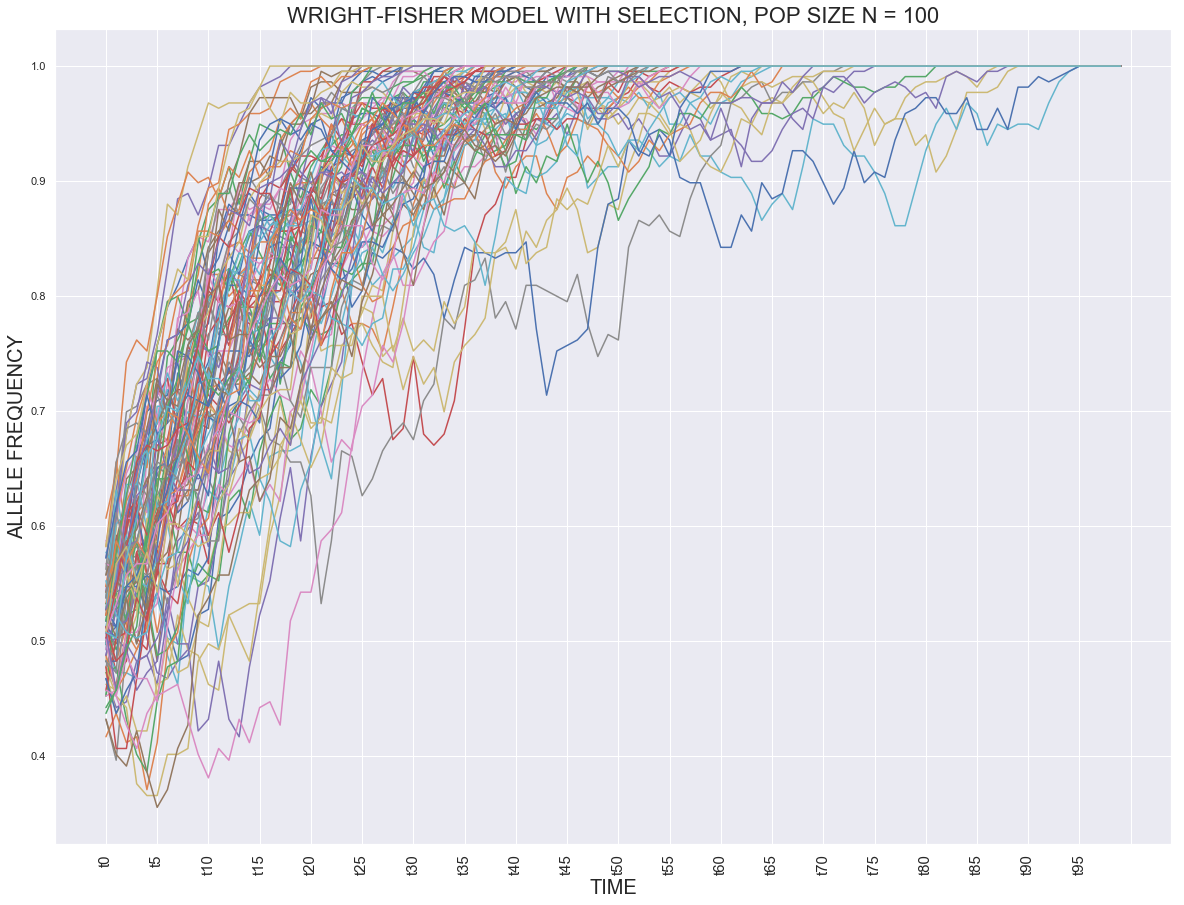

In [4]:
from pylab import rcParams
rcParams['figure.figsize'] = 20, 15
plt.rcParams.update({'font.size': 22})

sel_df.T.plot(legend = False)

plt.xticks(np.arange(0, len(list(sel_df.T.index)) + 1, 5), list(sel_df.T.index)[::5], fontsize = 15, rotation = 90)
plt.ylabel('ALLELE FREQUENCY', fontsize = 20)
plt.xlabel('TIME', fontsize = 20)
plt.title('WRIGHT-FISHER MODEL WITH SELECTION, POP SIZE N = ' + str(N), fontsize = 22)

plt.show()

When a weak selection has been added to the Wright-Fisher model, almost all alternative alleles have a tendency to increase their frequency because this leads to an increase in fitness. The fixation seems to can be reached faster compared to the genetic drift but the trajectories are still somewhat wobbly and can be easily confused with genetic drift. Let us visualize separately first trajectories from the genetic drift and selection models for taking a closer look at them. We can observe that even though both trajectories seem to go to fixation at some point, their profiles are very different. While the genetic drift (red) trajectory is very wobbly and goes up and down a lot on its way to fixation, the selection trajectory is much smoother and reaches a fixation without much fluctuation.

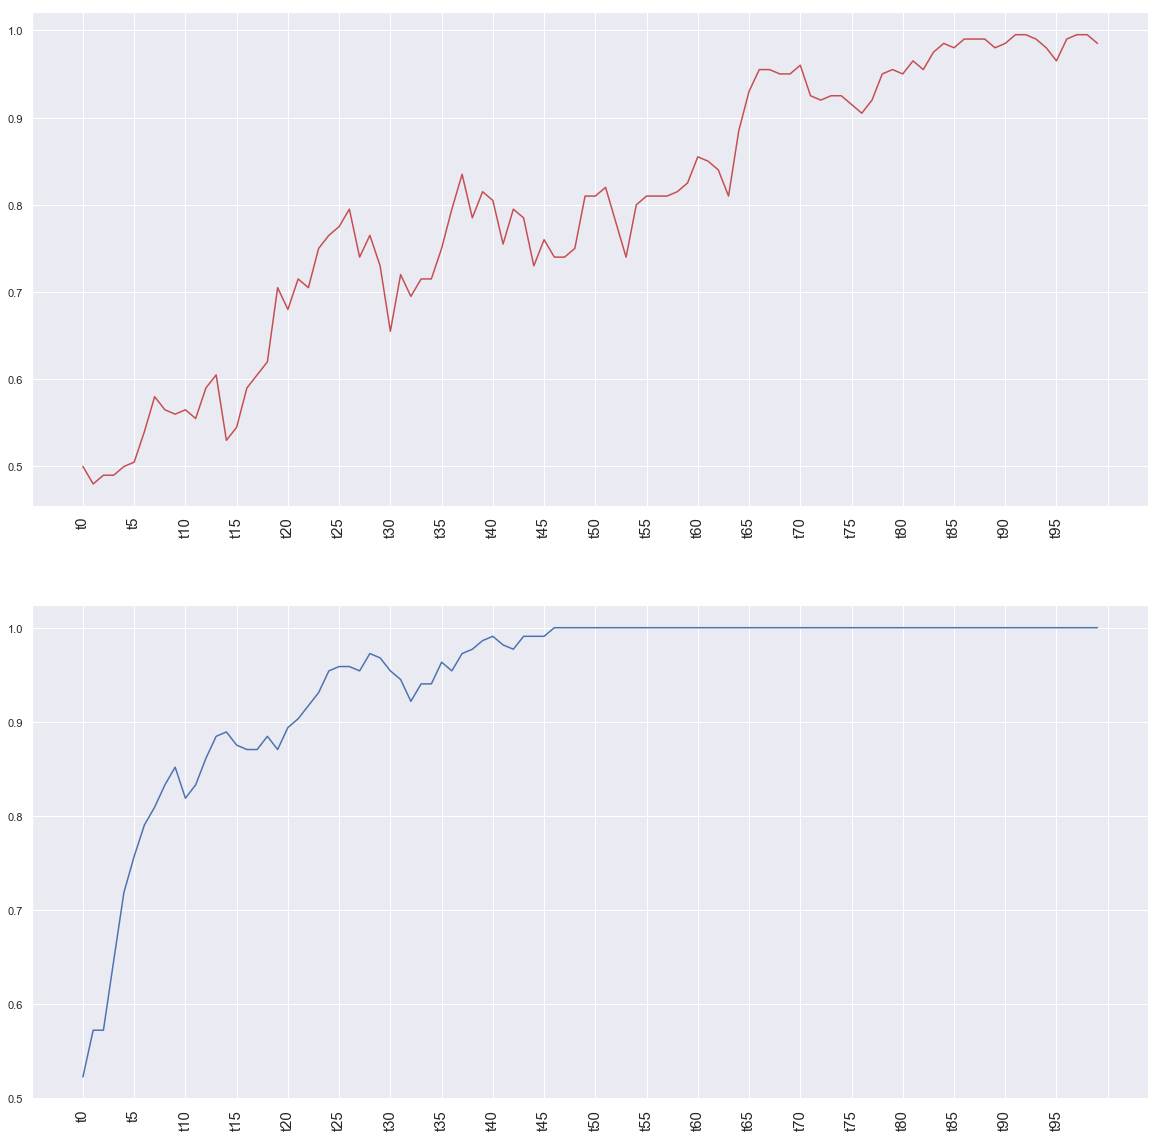

In [5]:
import matplotlib.pyplot as plt

drift_traj = drift_df.iloc[0,:]
sel_traj = sel_df.iloc[0,:]

# Plot allele fixation due to drift and selection next to each other
plt.figure(figsize = (20, 20))
plt.subplot(2, 1, 1)
plt.plot(drift_traj, color = 'r')
plt.xticks(np.arange(0, len(list(drift_df.T.index)) + 1, 5), list(drift_df.T.index)[::5], 
           fontsize = 15, rotation = 90)

plt.subplot(2, 1, 2)
plt.plot(sel_traj)
plt.xticks(np.arange(0, len(list(sel_df.T.index)) + 1, 5), list(sel_df.T.index)[::5], 
           fontsize = 15, rotation = 90)
    
plt.show()

Now, if we look at their autocorrelation functions after differencing operation, we can see that all the points for genetic drift lie within the confidence intervals of noise, while there are at least two points outside of the confidence intervals for the selection autocorrelation function (they gradually decrease down to the noise zone) that indicate the presense of long-range correlations from step to step along the selection trajectory.

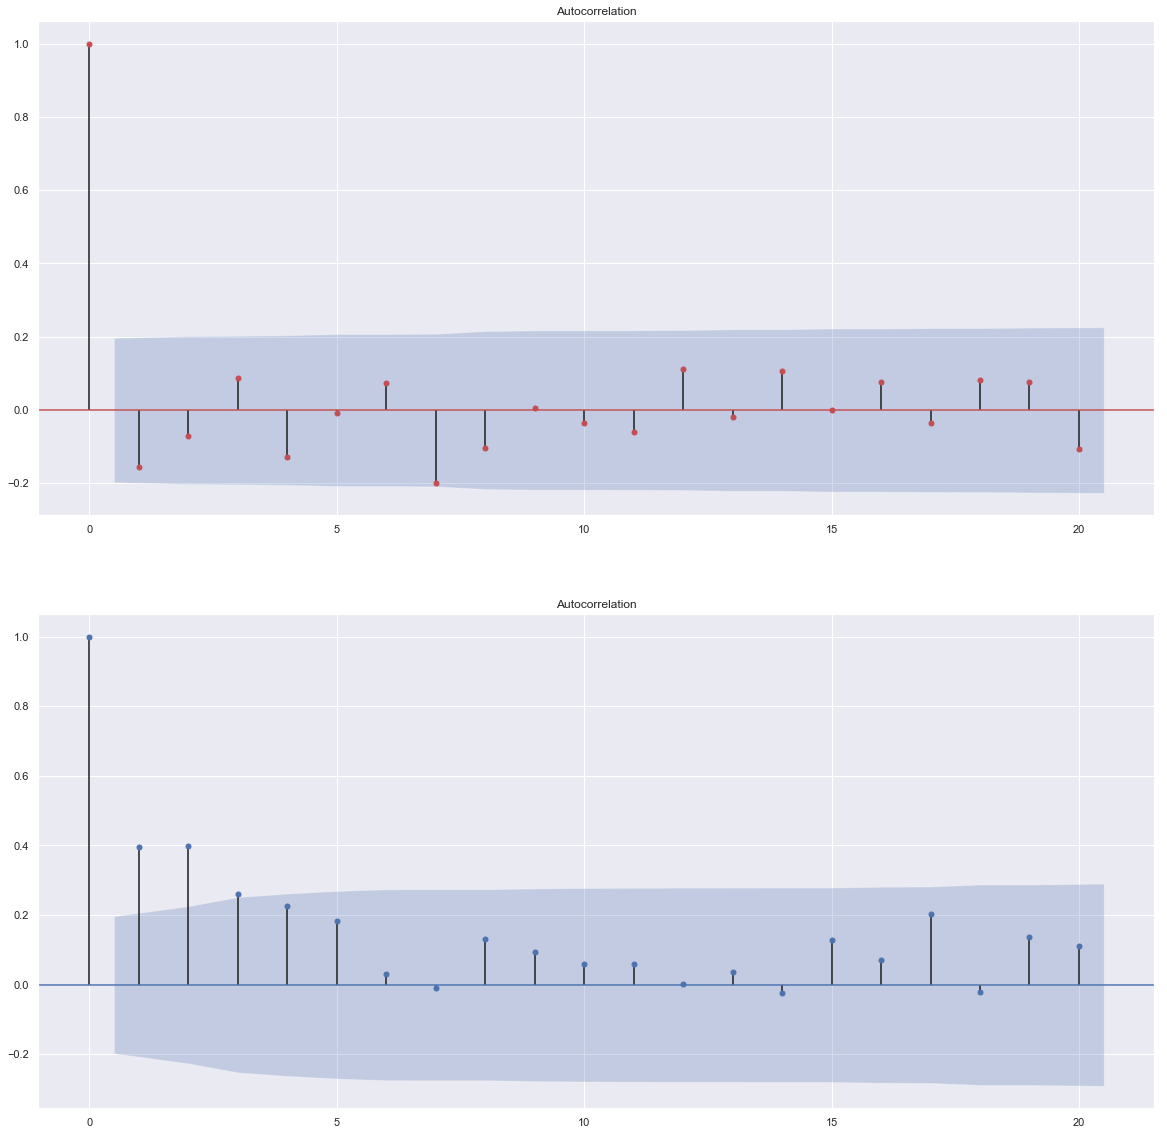

In [6]:
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(2, 1,figsize = (20, 20))

plot_acf(pd.Series(drift_traj).diff().dropna(), lags = 20, color = 'r', ax = ax[0])
plot_acf(pd.Series(sel_traj).diff().dropna(), lags = 20, color = 'b', ax = ax[1])

plt.show()

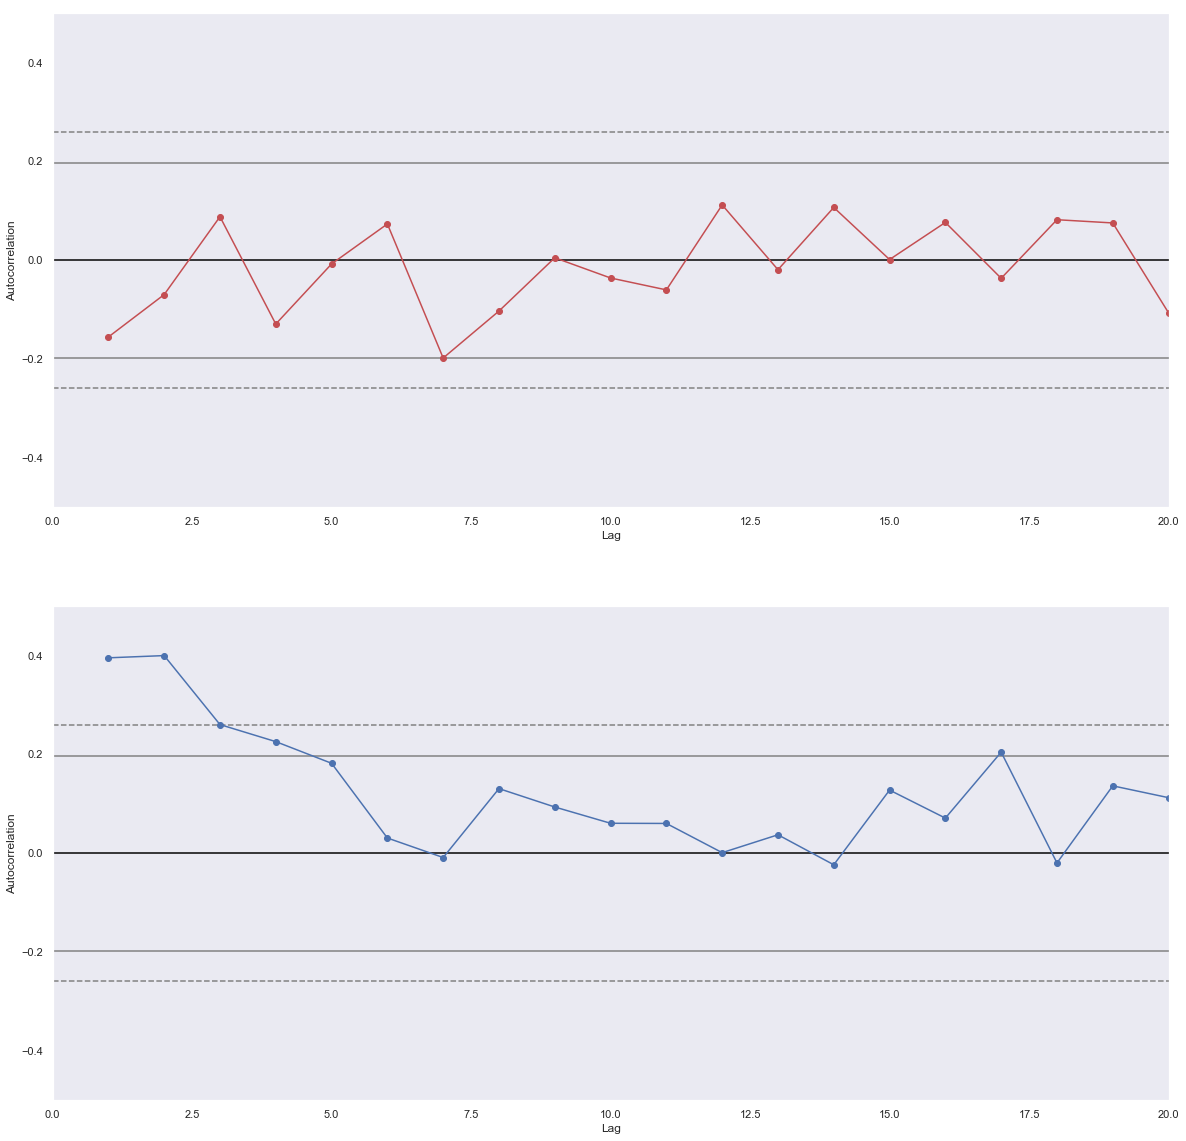

In [7]:
from pandas.plotting import autocorrelation_plot

fig, ax = plt.subplots(2, 1, figsize = (20, 20))

ax[0].set_ylim([-0.5, 0.5])
ax[1].set_ylim([-0.5, 0.5])

autocorrelation_plot(pd.Series(drift_traj).diff().dropna(), color = 'r', ax = ax[0], 
                     marker = 'o').set_xlim([0, 20])
autocorrelation_plot(pd.Series(sel_traj).diff().dropna(), color = 'b', ax = ax[1], marker = 'o').set_xlim([0, 20])

plt.show()

The augmented Dickey-Fuller test confirms that the genetic drift Wright-Fisher trajectory is a random walk, i.e. it is a stationary process after differencing, while the selection Wright-Fisher trajectory is significantly different from random walk.

In [8]:
from statsmodels.tsa.stattools import adfuller

results = adfuller(drift_traj)

print(f"ADF Statistic: {results[0]}")
print(f"p-value: {results[1]}")
print("Critical Values:")
for key, value in results[4].items():
    print("\t%s: %.3f" % (key, value))

ADF Statistic: -1.7022068376632469
p-value: 0.42997580790967127
Critical Values:
	1%: -3.499
	5%: -2.892
	10%: -2.583


In [9]:
from statsmodels.tsa.stattools import adfuller

results = adfuller(sel_traj)

print(f"ADF Statistic: {results[0]}")
print(f"p-value: {results[1]}")
print("Critical Values:")
for key, value in results[4].items():
    print("\t%s: %.3f" % (key, value))

ADF Statistic: -3.4655390764751255
p-value: 0.008917506666141726
Critical Values:
	1%: -3.504
	5%: -2.894
	10%: -2.584
